<a href="https://colab.research.google.com/github/AbhisekWebDev/passenger-vehicle-analytics/blob/main/passenger_car_analysis_ev_trend.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import sqlite3

# 1. Load the cleaned Excel dataset
file_path = "/Pro-Cars-2026-Copy.xlsx"
df = pd.read_excel(file_path)

# print(df)

# 2. Standardize string formatting in Region_Type
df["Region_Type"] = df["Region_Type"].astype(str).str.strip().str.lower()

# 3. Create an in-memory SQLite database
conn = sqlite3.connect(":memory:")

# 4. Transfer the DataFrame into a SQL table named 'passenger_cars'
df.to_sql("passenger_cars", conn, index=False, if_exists="replace")

# 5. Execute SQL Query: Top 5 producing countries comparing 2022 vs 2026
sql_query = """
    SELECT
        Country_Region,
        Production_2022,
        Production_2026
    FROM passenger_cars
    WHERE Region_Type = 'country'
    ORDER BY Production_2026 DESC
    LIMIT 5;
"""

# 6. Execute query and fetch results back into Pandas
top_countries = pd.read_sql_query(sql_query, conn)

print("--- Top 5 Car Producing Countries (2022 vs 2026) ---")
print(top_countries)

--- Top 5 Car Producing Countries (2022 vs 2026) ---
               Country_Region  Production_2022  Production_2026
0                       CHINA        5499168.0        5908720.0
1                       JAPAN        1648522.0        1885704.0
2                       INDIA        1075908.0        1571859.0
3                     GERMANY         826432.0        1068952.0
4  EUROPEAN UNION New Members         839185.0         997986.0


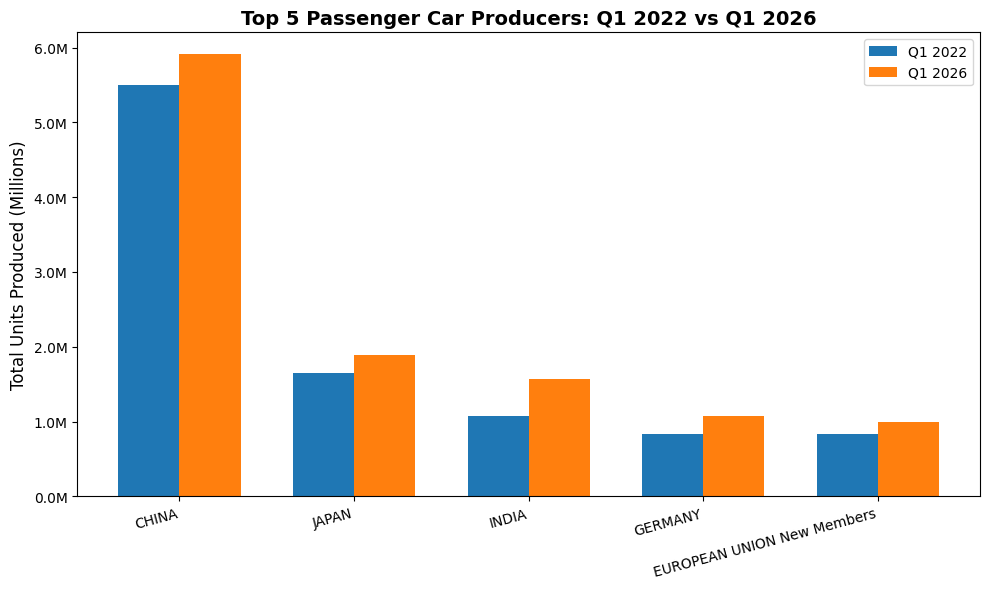

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare the data for plotting
countries = top_countries['Country_Region'].tolist()
prod_2022 = top_countries['Production_2022'].tolist()
prod_2026 = top_countries['Production_2026'].tolist()

# 2. Set up the bar positions
x = np.arange(len(countries))  # The label locations
width = 0.35  # The width of the bars

# 3. Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, prod_2022, width, label='Q1 2022', color='#1f77b4')
rects2 = ax.bar(x + width/2, prod_2026, width, label='Q1 2026', color='#ff7f0e')

# 4. Add labels, title, and formatting
ax.set_ylabel('Total Units Produced (Millions)', fontsize=12)
ax.set_title('Top 5 Passenger Car Producers: Q1 2022 vs Q1 2026', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(countries, rotation=15, ha='right')
ax.legend()

# 5. Format the y-axis to show millions (e.g., "6M" instead of "6000000")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}M".format(x/1000000)))

# 6. Display the chart cleanly
plt.tight_layout()
plt.show()

--- India EV Sales Data (Filtered) ---
powertrain      BEV  FCEV   PHEV
year                            
2019          680.0   0.0    7.0
2020         3100.0   0.0   43.0
2021        12000.0   1.0   50.0
2022        48000.0   2.0   23.0
2023        82000.0   0.0  270.0


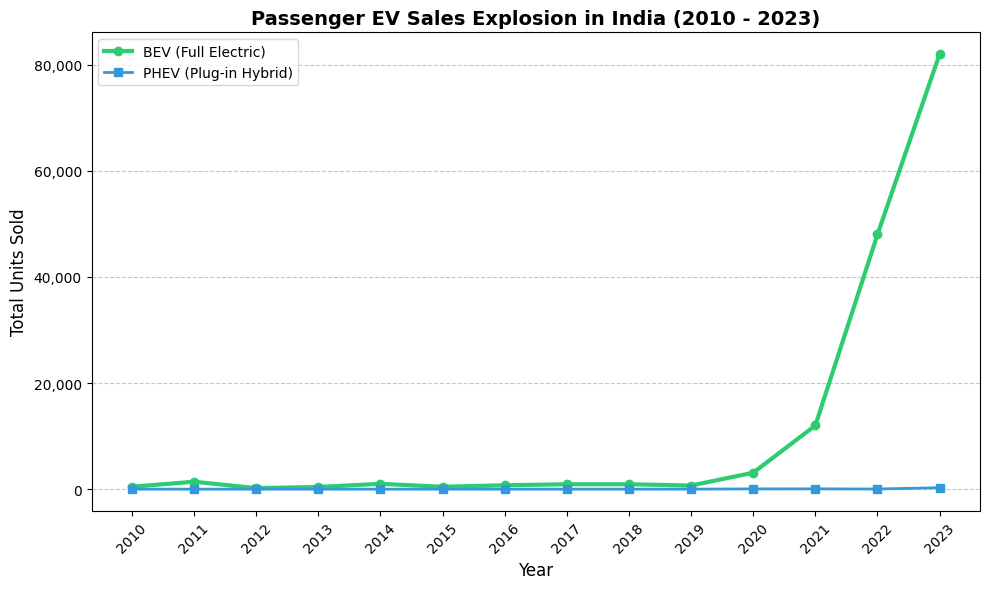

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "/content/IEA Global EV Data 2024.csv"
df = pd.read_csv(file_path)

# print(df)

# 1. Filter the dataset for Historical Passenger Car Sales in India
df_india_sales = df[
    (df['region'] == 'India') &
    (df['mode'] == 'Cars') &
    (df['category'] == 'Historical') &
    (df['parameter'] == 'EV sales')
]

# 2. Pivot the data to group by Year and Powertrain (BEV vs PHEV)
india_pivot = df_india_sales.pivot_table(
    index='year',
    columns='powertrain',
    values='value',
    aggfunc='sum'
).fillna(0) # Fill NaN values with 0

# Convert the index (years) to integers so they plot nicely without decimals
india_pivot.index = india_pivot.index.astype(int)

print("--- India EV Sales Data (Filtered) ---")
print(india_pivot.tail(5)) # Show the last 5 years of data

# Create the figure and axis object
fig, ax = plt.subplots(figsize=(10, 6))

# Plot BEV (Battery Electric Vehicles)
ax.plot(india_pivot.index, india_pivot['BEV'], marker='o', linewidth=3, color='#2ecc71', label='BEV (Full Electric)')

# Plot PHEV (Plug-in Hybrid Electric Vehicles)
if 'PHEV' in india_pivot.columns:
    ax.plot(india_pivot.index, india_pivot['PHEV'], marker='s', linewidth=2, color='#3498db', label='PHEV (Plug-in Hybrid)')

ax.set_title('Passenger EV Sales Explosion in India (2010 - 2023)', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Units Sold', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.set_xticks(india_pivot.index)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend()

# Format y-axis with commas for readability
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.show()

